In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
RANDOMSTATE = 42
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from scipy.stats import norm
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, classification_report
from scipy.stats import uniform
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings 
from torch.utils.data import DataLoader, TensorDataset
from tqdm import  tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from pathlib import Path
import pickle

## EDA

### Load Data

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

### Basic Info

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Target Analysis

======= Churn Distribution =======
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


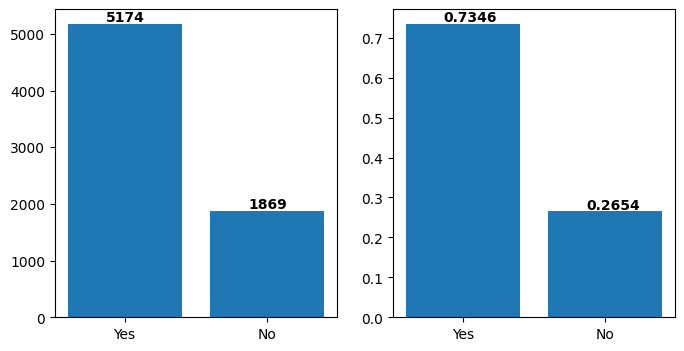

In [24]:
print(f'======= Churn Distribution =======')
value_count = df['Churn'].value_counts()
normalized_value_count = df['Churn'].value_counts(normalize = True )
print(value_count)
print(normalized_value_count)
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
bar_cnt = axes[0].bar(['Yes', 'No'], value_count.values)
for bar, val in zip(bar_cnt, value_count):
    axes[0].text(bar.get_x()+ bar.get_width()/3.0, bar.get_height()+ 50,
    f'{val}', fontweight = 'bold')

bar_normalized = axes[1].bar(['Yes', 'No'], normalized_value_count.values)
for bar, val in zip(bar_normalized, normalized_value_count):
    axes[1].text(bar.get_x()+ bar.get_width()/3.0, bar.get_height()+0.006 , 
    f'{val:.4f}', fontweight = 'bold')

Easy to notice data is Imbalanced <br>
I will handle it After Scaling and before train 

### Feature Analysis

In [10]:
# Check the number of unique entries per column
df_columns = list(df.columns)
for i, feature in enumerate(df_columns):
    print(f'{feature} unique values: {df[feature].nunique()}, dtype: {df[feature].dtype}')
    print('----------------')

customerID unique values: 7043, dtype: str
----------------
gender unique values: 2, dtype: str
----------------
SeniorCitizen unique values: 2, dtype: int64
----------------
Partner unique values: 2, dtype: str
----------------
Dependents unique values: 2, dtype: str
----------------
tenure unique values: 73, dtype: int64
----------------
PhoneService unique values: 2, dtype: str
----------------
MultipleLines unique values: 3, dtype: str
----------------
InternetService unique values: 3, dtype: str
----------------
OnlineSecurity unique values: 3, dtype: str
----------------
OnlineBackup unique values: 3, dtype: str
----------------
DeviceProtection unique values: 3, dtype: str
----------------
TechSupport unique values: 3, dtype: str
----------------
StreamingTV unique values: 3, dtype: str
----------------
StreamingMovies unique values: 3, dtype: str
----------------
Contract unique values: 3, dtype: str
----------------
PaperlessBilling unique values: 2, dtype: str
---------------

- No high cardinality

make sure Nan not a label in features has more than 2 labels 

In [11]:
cont_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_list = df_columns.copy()
for i in range (len(cont_col)):
    cat_list.remove(cont_col[i])
cat_list.remove('Churn')
cat_list.remove('customerID')
print(len(cat_list))

16


convert numeric feature from object type to float

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

check null values 

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
print(f'number of missing values= {df["TotalCharges"].isnull().sum()}')

number of missing values= 11


check is Nan values is new brand customers

In [16]:
for feature in cont_col:
    print(f'{feature} has {(df[feature] == 0).sum()} zeros ')

tenure has 11 zeros 
MonthlyCharges has 0 zeros 
TotalCharges has 0 zeros 


In [17]:
df[df['tenure']== 0][['tenure', 'TotalCharges', 'MonthlyCharges']]

,tenure,TotalCharges,MonthlyCharges
488,0,NaN,52.55
753,0,NaN,20.25
936,0,NaN,80.85
1082,0,NaN,25.75
1340,0,NaN,56.05
3331,0,NaN,19.85
3826,0,NaN,25.35
4380,0,NaN,20.00
5218,0,NaN,19.70
6670,0,NaN,73.35


this indicate that they are brand new customers<br>
After indicate that they are valid data, i will impute NaN with 0 <br>

#### Columns distribution

tenure skewness = 0.2395397495619829
MonthlyCharges skewness = -0.22052443394398033
TotalCharges skewness = 0.961642499724251


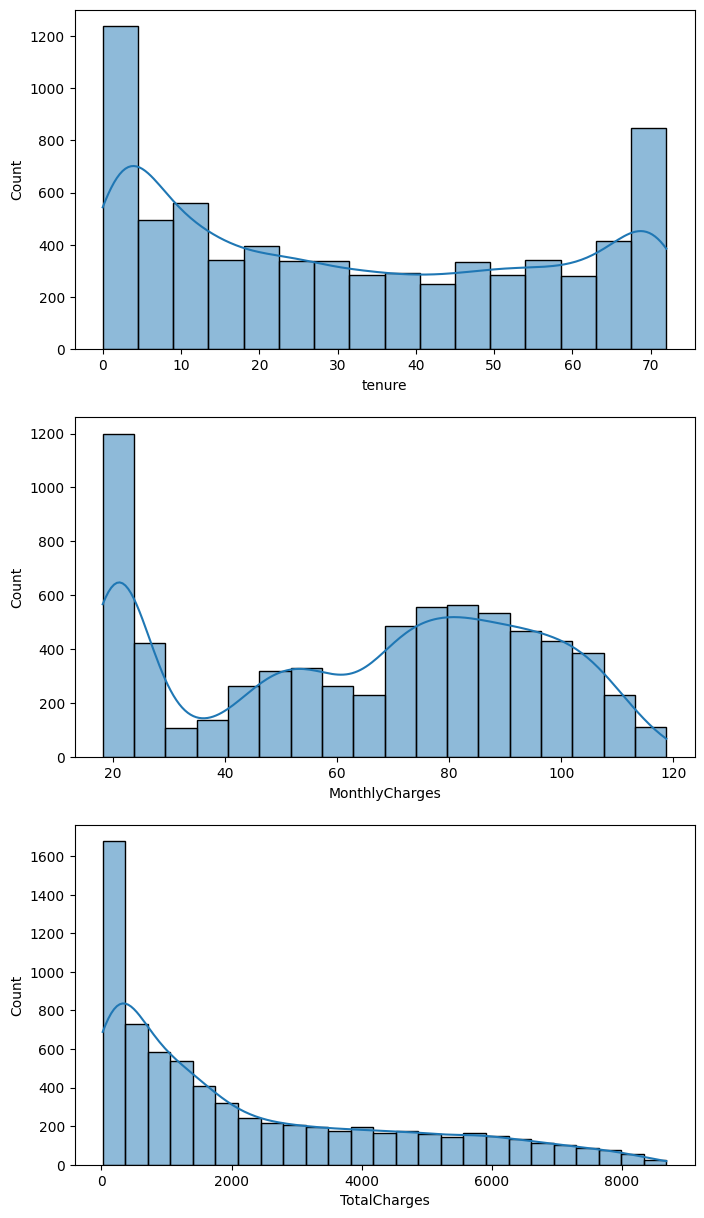

In [18]:
fig, axes = plt.subplots(3, 1, figsize =(8, 15))
for i, axis in enumerate(axes):
    print(f"{cont_col[i]} skewness = {df[cont_col[i]].skew()}")
    sns.histplot(data = df, x = cont_col[i], ax= axis, kde=True)

<Axes: xlabel='Churn', ylabel='tenure'>

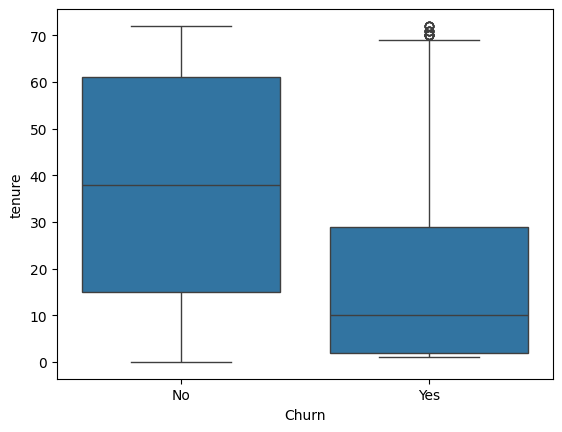

In [19]:
sns.boxplot(data= df, x = 'Churn', y= 'tenure')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

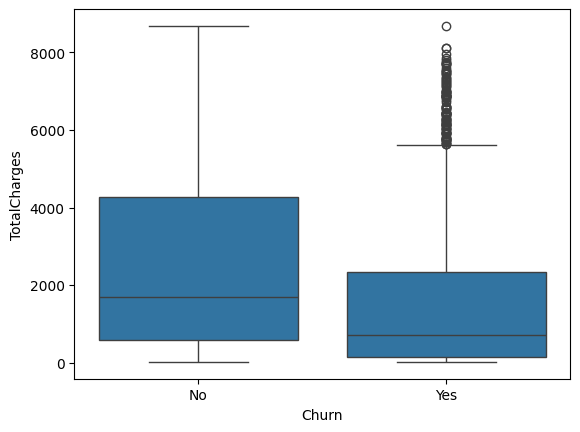

In [20]:
sns.boxplot(data= df, x = 'Churn', y= 'TotalCharges')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

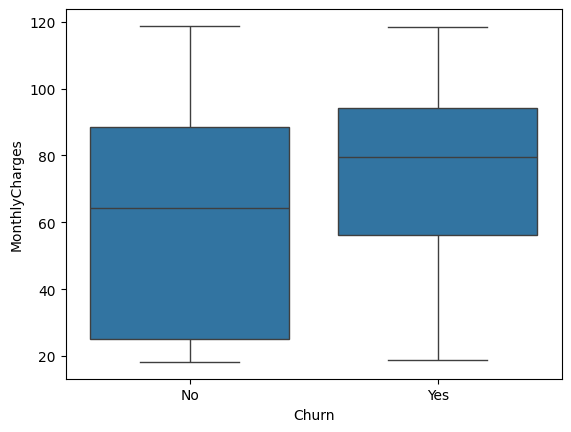

In [21]:
sns.boxplot(data= df, x = 'Churn', y= 'MonthlyCharges')

#### Visualizing Categorical Distributions with Countplots

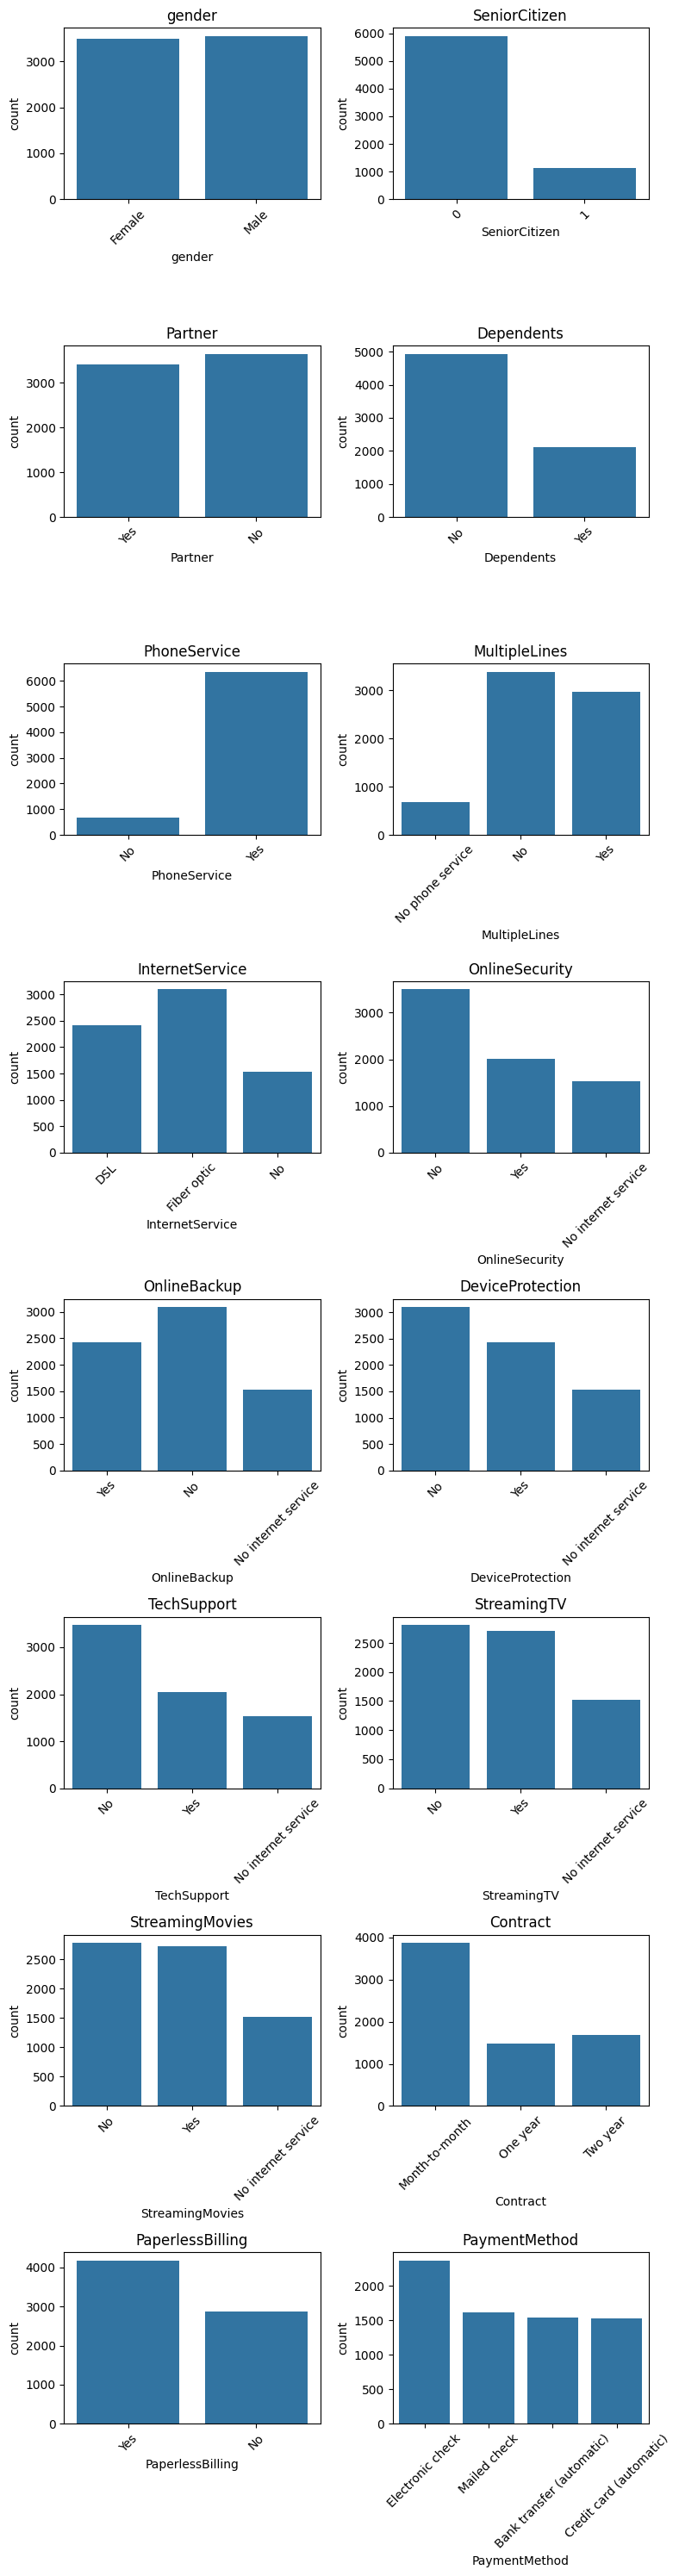

In [22]:
fig, axes = plt.subplots(8, 2, figsize = (8, 30))
axes = axes.flatten()
for i, feature in enumerate(cat_list):
    if i == 18:
        continue
    sns.countplot(data = df, x = feature, ax = axes[i])
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout() 
plt.show()

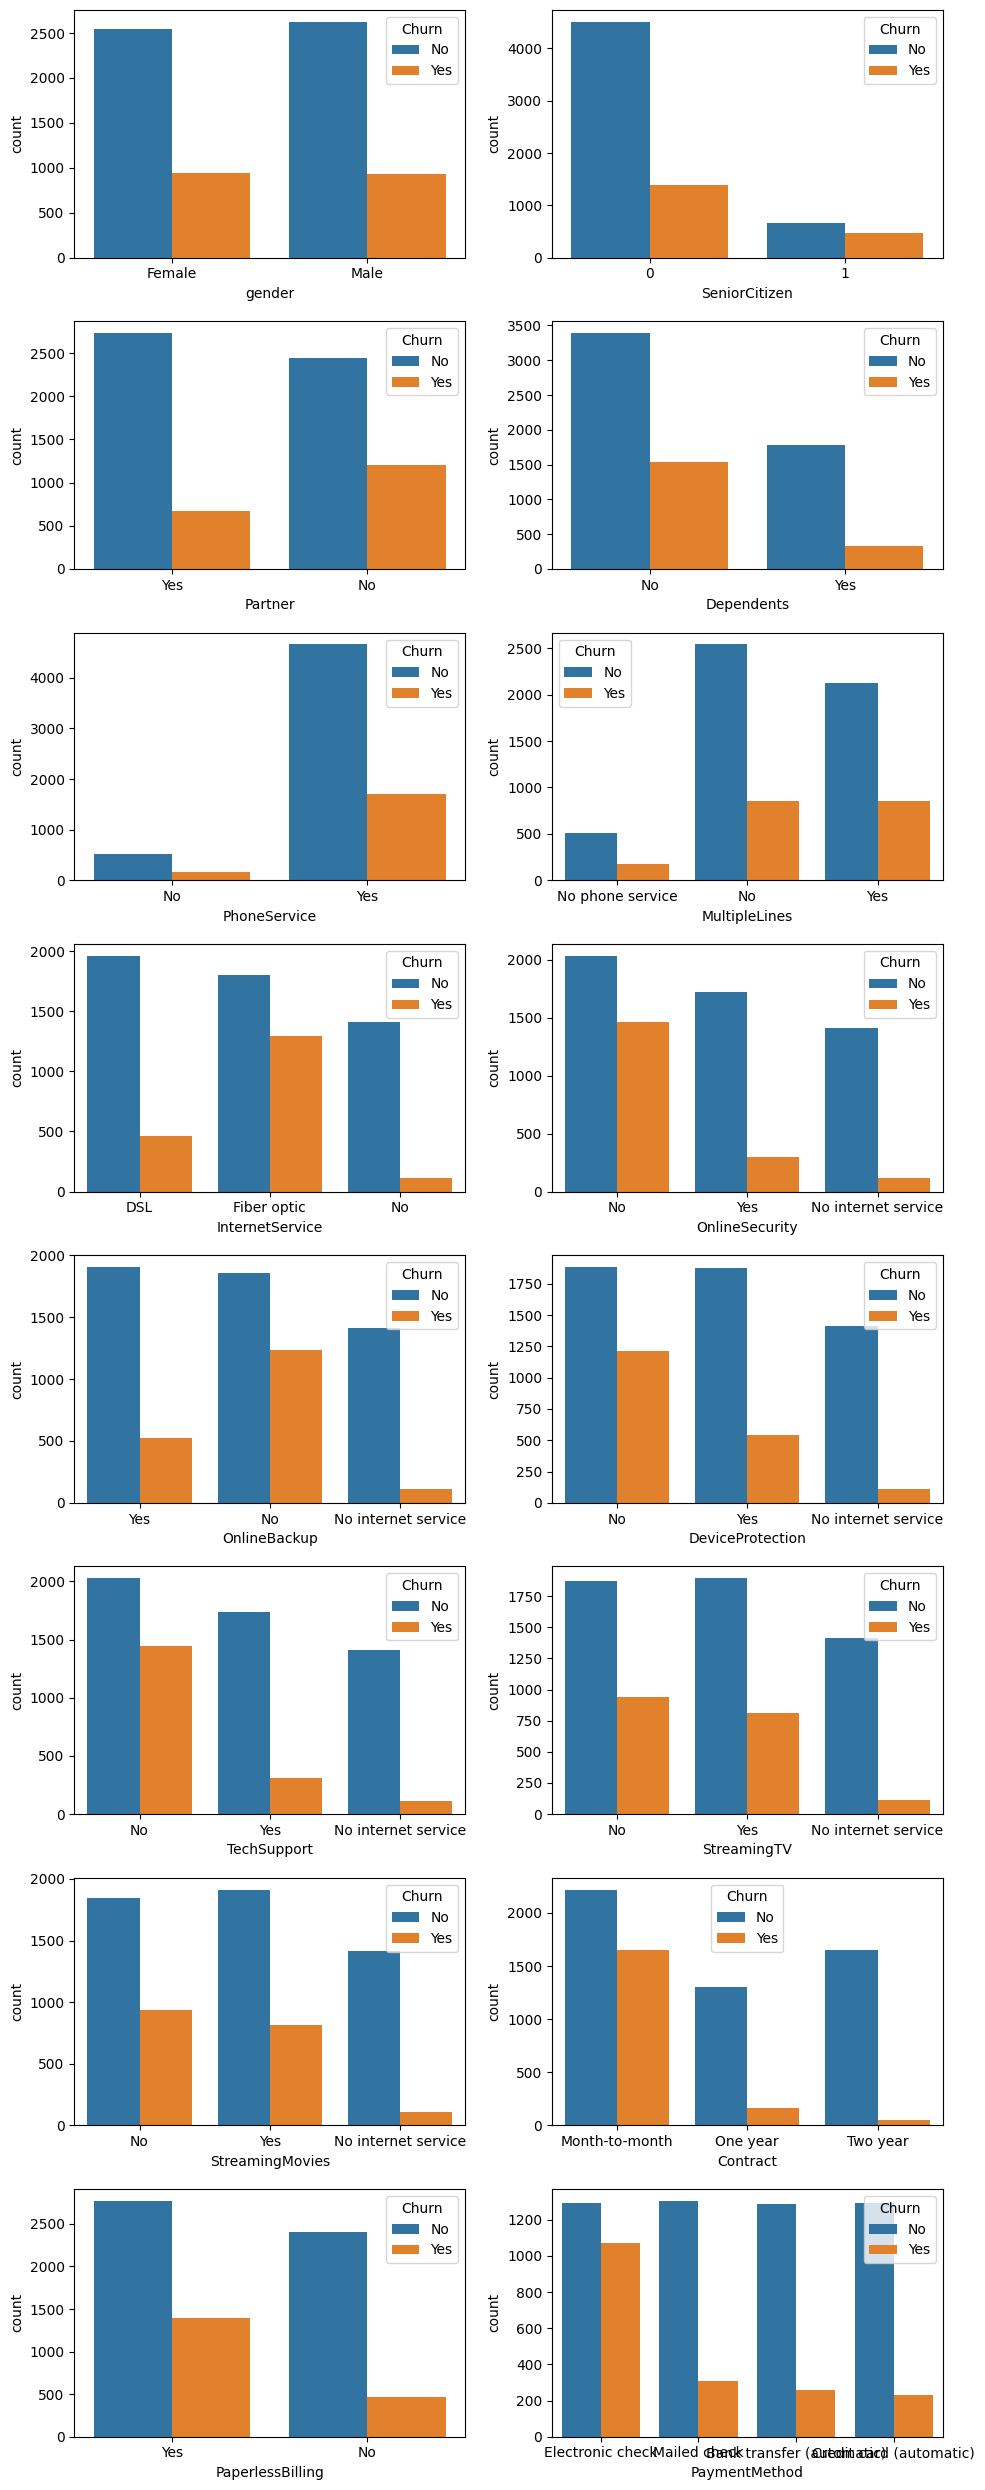

In [23]:
fig, axes = plt.subplots(8, 2, figsize = (10, 25))
axes = axes.flatten()
for i, feature in enumerate(cat_list):
    if i == 18:
        continue
    sns.countplot(data = df, x = feature, ax = axes[i], hue = 'Churn')

plt.tight_layout() 
plt.show()

#### Distribution of target variable across each continuous feature - check for separation and outliers

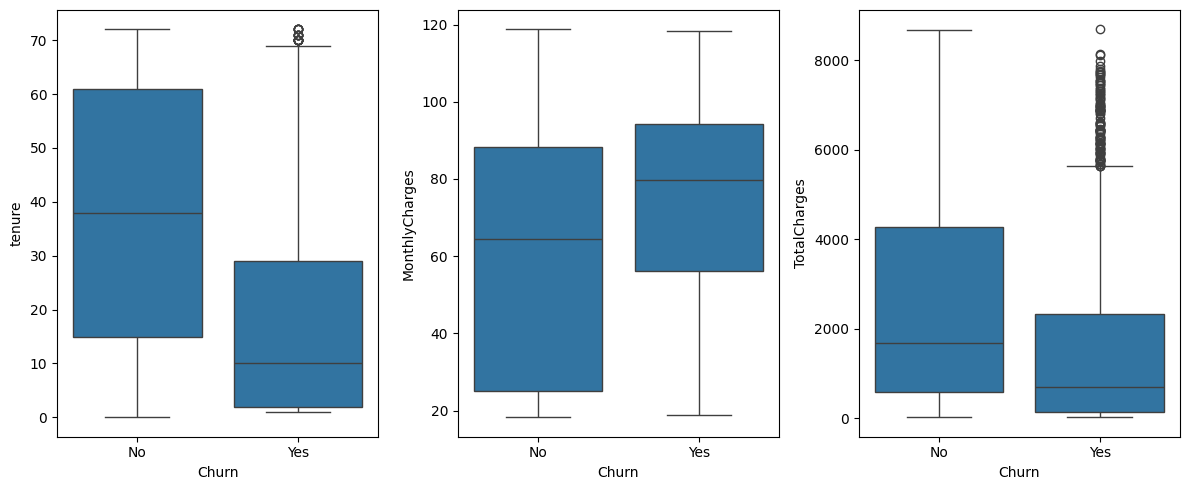

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12,5))
for i, feature in enumerate(cont_col):
    sns.boxplot(data = df, x = 'Churn', y = feature, ax = axes[i])
plt.tight_layout()
plt.show()

##### Outliers
- Tenure - no significant outliers in either classes<br>
- MonthlyCharges - no significant outliers in either classes<br>
- MonthlyCharges - no significant outliers in either classes<br>


#### Rename Churn labels

In [25]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

#### Correlation Matrix

<Axes: >

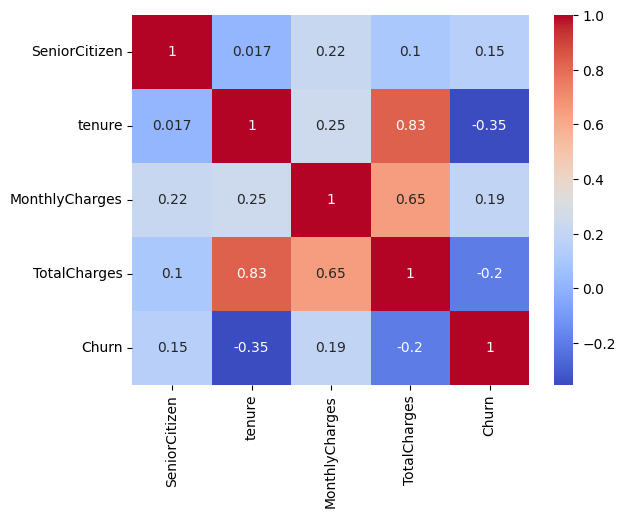

In [26]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

#### Separation
- Tenure(The best separation) 
&nbsp;&nbsp;&nbsp;&nbsp;**not churn**: median(38), IQR(18-60)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**Churn**: median(10), IQR(3-28)<br>

- **MonthlyCharges** (the weakest Separation)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(65), IQR(25-85)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(80), IQR(58-90)<br>

- **TotalCharges** (second best)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(1800), IQR(800-4200)<br>
&nbsp;&nbsp;&nbsp;&nbsp;**not Churn**: median(1000), IQR(500-2400)<br>

<br>
model can to a certain degree easily distinguish between the two classes using Tenure.

## Data Cleaning and Preprocessing

### Drop unique Identifier (unpredictive)

In [27]:
df.drop('customerID', axis = 1, inplace=True)

### Handle Duplicates

In [28]:
df.duplicated().sum()

np.int64(22)

In [29]:
df.drop_duplicates(inplace=True)

### Handle missing values

In [30]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [31]:
df['TotalCharges'].isnull().sum()

np.int64(0)

### split data 

In [32]:
df_train, df_temp, y_train, y_temp = train_test_split(df.drop('Churn', axis = 1), df['Churn'], test_size= 0.2, random_state=42)
df_val, df_test, y_val, y_test = train_test_split(df_temp, y_temp, test_size=0.5, random_state=42)

In [33]:
def log_transform(df):
    df['tenure'] = np.log(df['tenure']+ 1)
    return df

In [34]:
df_train = log_transform(df_train)
df_val = log_transform(df_val)
df_test = log_transform(df_test)

### Encoding

In [35]:
cat_nom = ['gender', 'Dependents', 'PaperlessBilling', 'PaymentMethod', 'Partner', 'PhoneService']
cat_ord = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract' ]

In [36]:
ordinal_categories = [
    ['No phone service', 'No', 'Yes',],
    ['No', 'DSL', 'Fiber optic'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['No internet service', 'No', 'Yes'],
    ['Month-to-month', 'One year', 'Two year'],
]

In [37]:
MyEncoding = ColumnTransformer(
    transformers=[
        ('nom', OneHotEncoder(drop= 'first', sparse_output=False), cat_nom),
        ('ord', OrdinalEncoder(categories = ordinal_categories), cat_ord)
    ],
    verbose_feature_names_out= False,
    remainder= 'passthrough',
    
)
MyEncoding.set_output(transform='pandas')
df_temp = MyEncoding.fit_transform(df_train)

### Feature Engineering 

<Axes: >

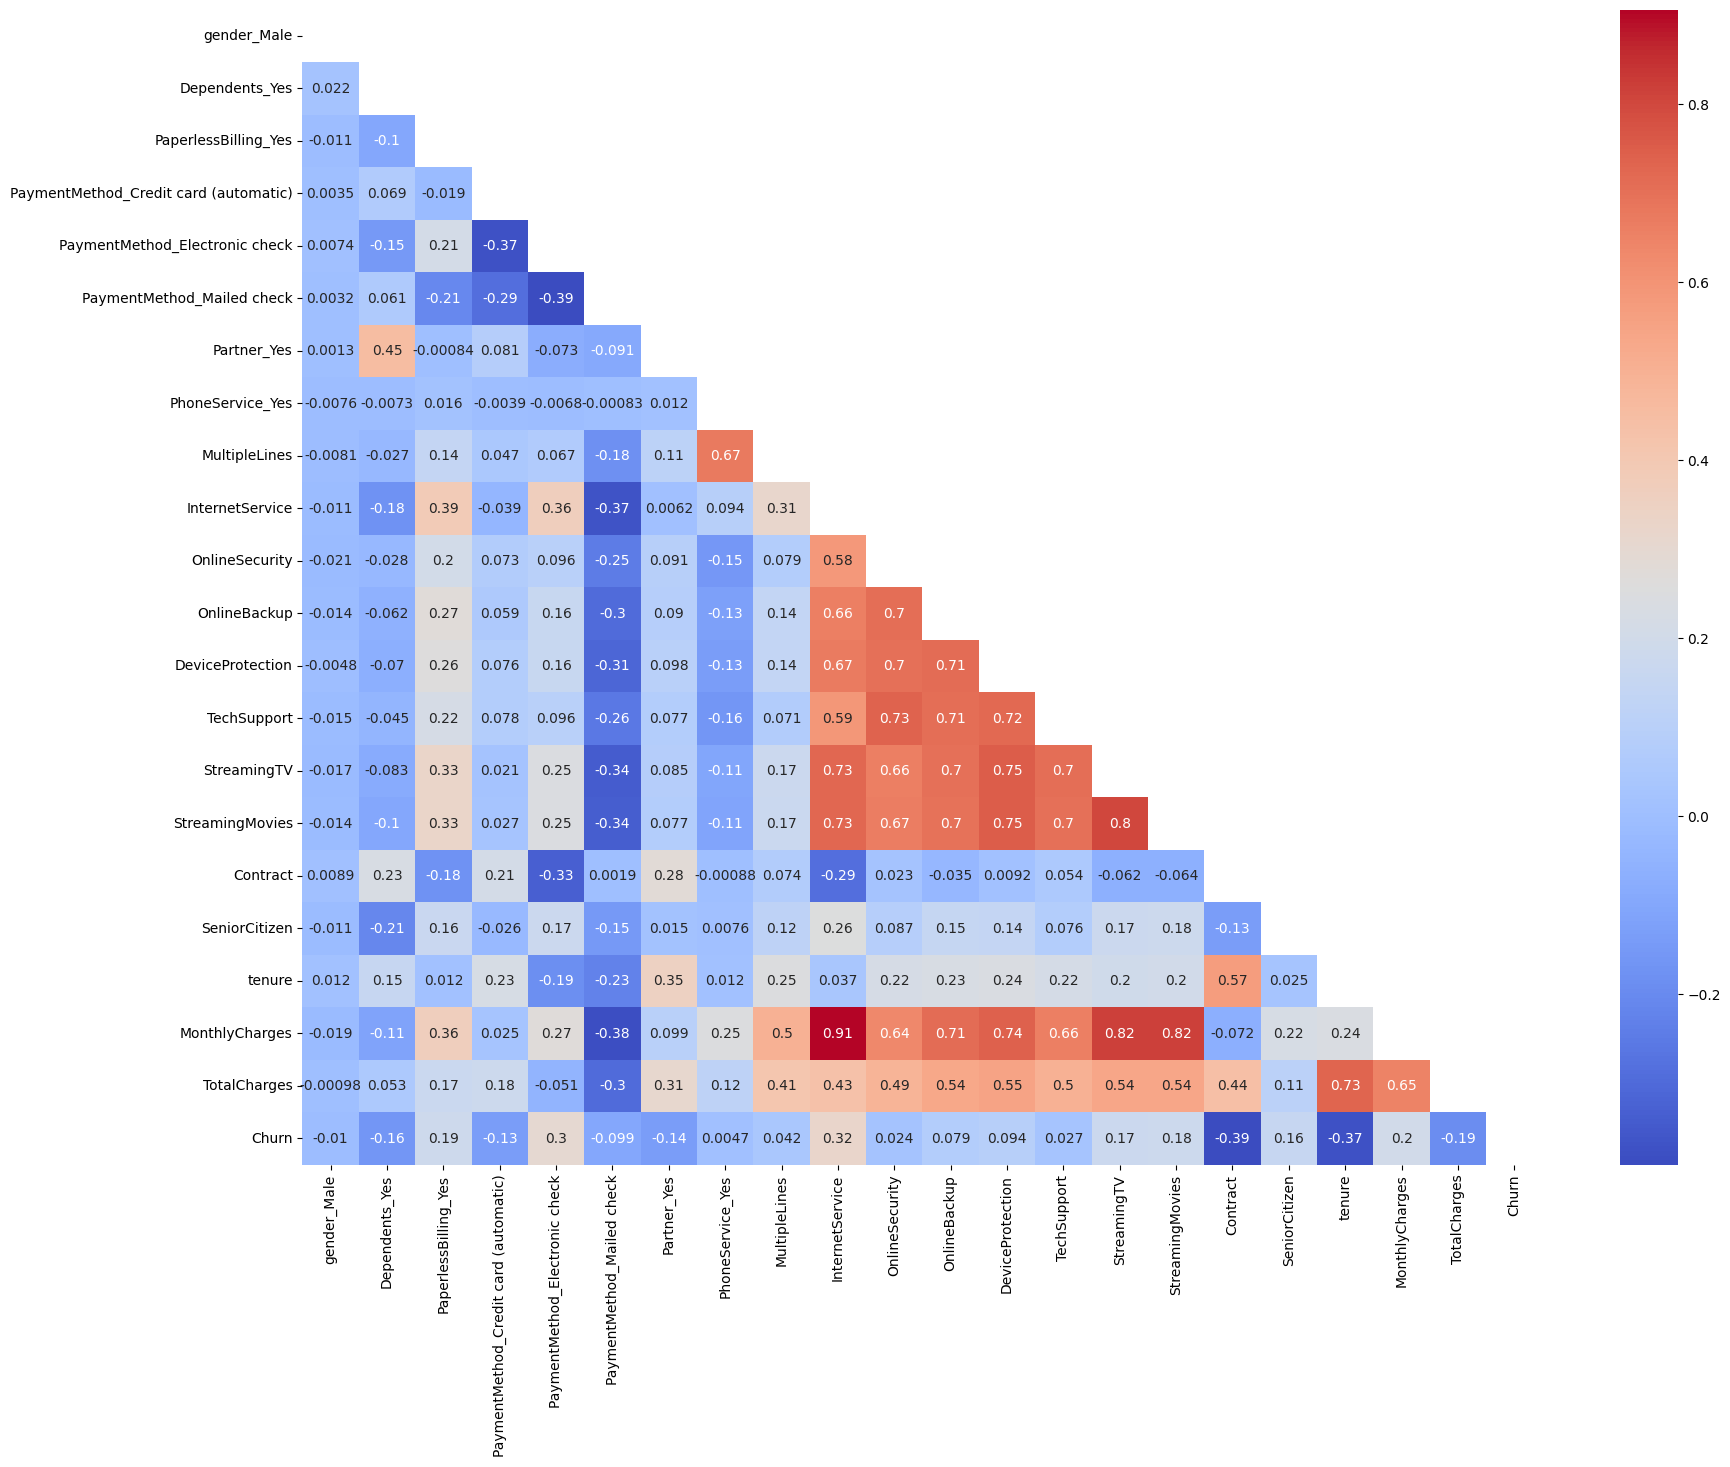

In [38]:
plt.figure(figsize=(20, 15))
corr = pd.concat([df_temp, y_train],axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask = mask, annot=True , annot_kws = {'size':10}, cmap = 'coolwarm')

- Internet-Related Features: I will replace the "No internet service" label into "No".
- Since InternetService has a high correlation with the target, I just removing the redundant sub-labels to simplify the model.

- Phone-Related Features: I will not clean the redundant "No phone service" labels.
- Because PhoneService and its related features show low correlation with the target, these features will be dropped entirely.

In [39]:
class FE(BaseEstimator, TransformerMixin):
    def fit(self, X, y= None ):
        return self
    
    def transform(self, X):
        X = X.copy()

        # romove redundant labels 
        cat_tofix= ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',]
        for feature in cat_tofix:
            X[feature]  = X[feature].replace({1: 0, 2:1})

        X['average_charges'] = X['TotalCharges'] / (X['tenure'] + 1)
        X['monthly_to_total'] = X['MonthlyCharges'] / (X['TotalCharges']+ 1)
        X['Family'] = X['Partner_Yes'] + X['Dependents_Yes']
        X = X.drop(['gender_Male','Dependents_Yes', 'Partner_Yes', 'TotalCharges', 'MonthlyCharges', 'tenure'], axis = 1)
        return X 
    
        
    def set_output(self, transform= None):
        self._transform_output = transform
        return self

### Scaling 

In [40]:
my_pipe = Pipeline([
    ('encoding', MyEncoding),
    ('fe', FE()),
    ('scaling', StandardScaler())
])

In [41]:
df_train_scaled = my_pipe.fit_transform(df_train)
df_val_scaled = my_pipe.transform(df_val)
df_test_scaled = my_pipe.transform(df_test)

In [42]:
MODELS_PATH = Path('Models')
MODELS_PATH.mkdir(parents= True, exist_ok= True)

In [ ]:
pipe_name = 'pipeline.pickle'
save_pipe = MODELS_PATH/ pipe_name
try:
    if not save_pipe.exists():
        with open(save_pipe, 'wb')as f:
            pickle.dump(my_pipe, f)
        if save_pipe.exists():
            print('Successfully saved')
        else :
            raise PermissionError(f"Permission denied: Cannot create files in '{save_pipe}'.")
    
    elif save_pipe.exists():
        print('File Already Exist!')

except PermissionError as e:
    print(f'Error: {e}')


Successfully saved


## Training & Evaluation

### Linear models

#### SGDClassifier

In [44]:
sgdc = SGDClassifier(loss= 'log_loss',penalty='l2', random_state=42, alpha= 2, class_weight= 'balanced')
sgdc.fit(df_train_scaled, y_train)
train_pred =sgdc.predict_proba(df_train_scaled)[:, 1]
val_pred =sgdc.predict_proba(df_val_scaled)[:, 1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.6107099260474294
Val AP-Score: 0.6046007669880423


In [45]:
test_pred =sgdc.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.5800019752143122


In [46]:
AP_score = average_precision_score(y_test, sgdc.predict_proba(df_test_scaled)[:, 1])
y_pred = sgdc.predict(df_test_scaled)
acc = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
sgdc_score = pd.Series([AP_score, acc, F1_score , precision, recall])
print(sgdc_score)

0    0.580002
1    0.733997
2    0.587196
3    0.480144
4    0.755682
dtype: float64


#### LogisticRegression 

In [47]:
log_reg = LogisticRegression(penalty='l2', C= 10, class_weight= 'balanced')
log_reg.fit(df_train_scaled, y_train)
train_pred =log_reg.predict_proba(df_train_scaled)[:, 1]
val_pred =log_reg.predict_proba(df_val_scaled)[:, 1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.652749038121308
Val AP-Score: 0.6283540715872002


c:\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [48]:
test_pred =log_reg.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.6237800897155026


In [49]:
AP_score = average_precision_score(y_test, log_reg.predict_proba(df_test_scaled)[:, 1])
y_pred = log_reg.predict(df_test_scaled)
acc = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
log_reg_score = pd.Series([AP_score, acc, F1_score , precision, recall])
print(log_reg_score)

0    0.623780
1    0.743954
2    0.606987
3    0.492908
4    0.789773
dtype: float64


### Ensemble models

#### Random Forest

##### random search

In [50]:
from scipy.stats import randint
rand_param = {
    'n_estimators': randint(80, 400),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2,5), 
    'max_features': uniform(0, 1),
    'max_samples': uniform(0, 1),          
    'class_weight': [None, 'balanced']
}

In [51]:
rand_forest = RandomForestClassifier(random_state=42)
rand_search_forest = RandomizedSearchCV(
    rand_forest,
    rand_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    verbose = 1,
    n_iter =50,
    random_state=42
)
rand_search_forest.fit(df_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': <scipy.stats....002B131B5B390>, 'max_features': <scipy.stats....002B0EBC038C0>, 'max_samples': <scipy.stats....002B131B5B890>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for t

In [52]:
best_model_rand_forest = rand_search_forest.best_estimator_
print(f'n_estimator: {best_model_rand_forest.get_params()["n_estimators"]}')
print(f'max depth: {best_model_rand_forest.get_params()["max_depth"]}')
print(f'min_samples_split: {best_model_rand_forest.get_params()["min_samples_split"]}')
print(f'class weight: {best_model_rand_forest.get_params()["class_weight"]}')

n_estimator: 274
max depth: 7
min_samples_split: 4
class weight: None


In [53]:
train_pred = best_model_rand_forest.predict_proba(df_train_scaled)[:,1]
val_pred = best_model_rand_forest.predict_proba(df_val_scaled)[:,1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.7317513155588663
Val AP-Score: 0.6432280613762151


In [54]:
test_pred =best_model_rand_forest.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.6302324926862273


In [55]:
rand_forest = RandomForestClassifier(random_state=42, verbose = False )
grid_param = {
    'n_estimators': [270, 274, 280],
    'max_depth': [7, 10, 11],
    'min_samples_split': [3, 4],
    'class_weight': [None, 'balanced'],
    'max_features': [0.8, 0.9]
}
grid_search_forest = GridSearchCV(
    rand_forest,
    grid_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    verbose = False,
)
grid_search_forest.fit(df_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...verbose=False)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [7, 10, ...], 'max_features': [0.8, 0.9], 'min_samples_split': [3, 4], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [56]:
best_model_grid_forest = grid_search_forest.best_estimator_
print(f'n_estimator: {best_model_grid_forest.get_params()["n_estimators"]}')
print(f'max depth: {best_model_grid_forest.get_params()["max_depth"]}')
print(f'min_samples_split: {best_model_grid_forest.get_params()["min_samples_split"]}')
print(f'class weight: {best_model_grid_forest.get_params()["class_weight"]}')

n_estimator: 280
max depth: 7
min_samples_split: 3
class weight: None


In [57]:
train_pred = best_model_grid_forest.predict_proba(df_train_scaled)[:,1]
val_pred = best_model_grid_forest.predict_proba(df_val_scaled)[:,1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.7692949539290614
Val AP-Score: 0.6307227075378852


In [58]:
test_pred =best_model_grid_forest.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.6331590857963262


In [59]:
AP_score = average_precision_score(y_test, best_model_rand_forest.predict_proba(df_test_scaled)[:, 1])
y_pred = best_model_rand_forest.predict(df_test_scaled)
acc = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
random_forest_score = pd.Series([AP_score, acc, F1_score , precision, recall])
print(random_forest_score)

0    0.630232
1    0.798009
2    0.526667
3    0.637097
4    0.448864
dtype: float64


In [60]:
from scipy.stats import randint
rand_param = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(1, 10),
    'reg_lambda': uniform(0,5), 
    'reg_alpha': uniform(0, 5), 
    'min_child_weight': randint(1, 10), 
    'gamma': uniform(0, 1),
    'learning_rate': uniform(0.05, 0.4),
    'scale_pos_weight': uniform(1, 6),
}
xgb = XGBClassifier(random_state =42, early_stopping_rounds = 50, eval_metric = 'aucpr')
rand_search_xgb = RandomizedSearchCV(
    xgb,
    rand_param,
    cv = 5,
    scoring='average_precision',
    n_jobs= -1,
    n_iter =100,
    random_state=42, 
    verbose= False
)
rand_search_xgb.fit(df_train_scaled, y_train, eval_set = [(df_val_scaled, y_val)], verbose = False)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'gamma': <scipy.stats....002B1331A88A0>, 'learning_rate': <scipy.stats....002B1319EA570>, 'max_depth': <scipy.stats....002B0EBD0F6F0>, 'min_child_weight': <scipy.stats....002B1319E9910>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User

In [61]:
best_model_xgb = rand_search_xgb.best_estimator_
print(f'n_estimator: {best_model_xgb.get_params()["n_estimators"]}')
print(f'lr: {best_model_xgb.get_params()["learning_rate"]}')
print(f'max depth: {best_model_xgb.get_params()["max_depth"]}')
print(f'reg lambda: {best_model_xgb.get_params()["reg_lambda"]}')
print(f'reg alpha: {best_model_xgb.get_params()["reg_alpha"]}')
print(f'Scale pos weight: {best_model_xgb.get_params()["scale_pos_weight"]}')
print(f'gamma: {best_model_xgb.get_params()["gamma"]}')

n_estimator: 189
lr: 0.253044151473782
max depth: 1
reg lambda: 0.4364508979483772
reg alpha: 3.838897507214194
Scale pos weight: 4.0366237381560826
gamma: 0.4254364386164168


In [62]:
train_pred = best_model_xgb.predict_proba(df_train_scaled)[:,1]
val_pred = best_model_xgb.predict_proba(df_val_scaled)[:,1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.6820540694621632
Val AP-Score: 0.64727374198317


In [63]:
test_pred =best_model_xgb.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.6230672633529128


In [64]:
AP_score = average_precision_score(y_test, best_model_xgb.predict_proba(df_test_scaled)[:, 1])
y_pred = best_model_xgb.predict(df_test_scaled)
acc = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
xgb_score = pd.Series([AP_score, acc, F1_score , precision, recall])
print(xgb_score)

0    0.623067
1    0.714083
2    0.612717
3    0.463557
4    0.903409
dtype: float64


In [65]:
estimated_weight = (y_train == 0).sum() /  (y_train == 1).sum()
print(estimated_weight)

2.73156146179402


In [66]:
rand_param = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),       
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 100),    
    'min_child_samples': randint(10, 50) ,
    'scale_pos_weight':uniform(1, 3)
}
lgbm = LGBMClassifier(random_state=42, verbose = -1)
rand_search_lgbm = RandomizedSearchCV(
    estimator=lgbm, 
    param_distributions=rand_param, 
    cv=5, 
    scoring='accuracy', 
    verbose=False,         
    n_iter=100,                   
)

rand_search_lgbm.fit(df_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....002B1331B07C0>, 'max_depth': <scipy.stats....002B1331B05A0>, 'min_child_samples': <scipy.stats....002B1331AC750>, 'n_estimators': <scipy.stats....002B0EBD43350>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`Use

In [67]:
best_model_lgbm = rand_search_lgbm.best_estimator_
train_pred = best_model_lgbm.predict_proba(df_train_scaled)[:,1]
val_pred = best_model_lgbm.predict_proba(df_val_scaled)[:,1]
print(f'Train AP-Score: {average_precision_score(y_train, train_pred)}')
print(f'Val AP-Score: {average_precision_score(y_val,val_pred)}')

Train AP-Score: 0.7751067330563265
Val AP-Score: 0.6178925883826062


In [68]:
test_pred =best_model_lgbm.predict_proba(df_test_scaled)[:, 1]
print(f'test AP-Score: {average_precision_score(y_test,test_pred)}')

test AP-Score: 0.6244987492910493


In [69]:
AP_score = average_precision_score(y_test, best_model_lgbm.predict_proba(df_test_scaled)[:, 1])
y_pred = best_model_lgbm.predict(df_test_scaled)
acc = accuracy_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
lgbm_score = pd.Series([AP_score, acc,  F1_score , precision, recall])
print(lgbm_score)

0    0.624499
1    0.792319
2    0.592179
3    0.582418
4    0.602273
dtype: float64


In [74]:
modeles_scores = pd.concat([sgdc_score, log_reg_score,random_forest_score, xgb_score, lgbm_score], axis = 1).T
modeles_scores.index = ['SGDC', 'LogisticRegression', 'RandomForestClassifier', 'XGBClassifier', 'LGBMClassifier']
modeles_scores.columns = ['AP', 'Accuracy', 'f1-score', 'precision', 'recall']
modeles_scores_sorted = modeles_scores.sort_values(by ='f1-score', ascending= False)
modeles_scores_sorted

,AP,Accuracy,f1-score,precision,recall
XGBClassifier,0.623067,0.714083,0.612717,0.463557,0.903409
LogisticRegression,0.623780,0.743954,0.606987,0.492908,0.789773
LGBMClassifier,0.624499,0.792319,0.592179,0.582418,0.602273
SGDC,0.580002,0.733997,0.587196,0.480144,0.755682
RandomForestClassifier,0.630232,0.798009,0.526667,0.637097,0.448864


In [168]:
xgbc_name = 'xgbc.pickle'
save_xgbc = MODELS_PATH/ xgbc_name
try:
    if not save_xgbc.exists():
        with open(save_xgbc, 'wb')as f:
            pickle.dump(rand_search_xgb.best_estimator_, f)
            if save_xgbc.exists():
                print('Successfully saved')
    
    elif save_xgbc.exists():
        print('File Already Exist!')
    
    else :
        raise PermissionError(f"Permission denied: Cannot create files in '{save_xgbc}'.")
except PermissionError as e:
    print(f'Error: {e}')


Successfully saved
